 Data Cleaning & EDA 

[1] Raw data loaded: 3931 rows × 224 columns
[2] Deduplicated: 2458 unique leads (latest per record_id)
[3] Selected 43 columns from 224
[4] Cleaned string values, standardized types
[5] Imputed missing values (numeric=median, categorical=Unknown)
[6] Dropped 6 columns (≥95% null+zero)
[7] No zero-variance columns

[8] Saved: scorify_cleaned_dataset.csv
    Final shape: 2458 rows × 37 columns
    Missing values: 0
EDA — Key Insights
------------------------------------------------------------

Dataset: 2458 leads, 34 features, 2 targets
  Numeric features:     19
  Categorical features: 15

Target 1 — target_conv_prob (conversion probability):
  Mean=0.0512, Median=0.0193, Std=0.0810
  Range=[0.0013, 0.6572]

Target 2 — target_profit (predicted profit if converted):
  Mean=112,378, Median=91,069, Std=69,478
  Range=[26,513, 669,781]

Top feature correlations with target_conv_prob:
  time_on_site                  : 0.3458
  total_sessions                : 0.3193
 

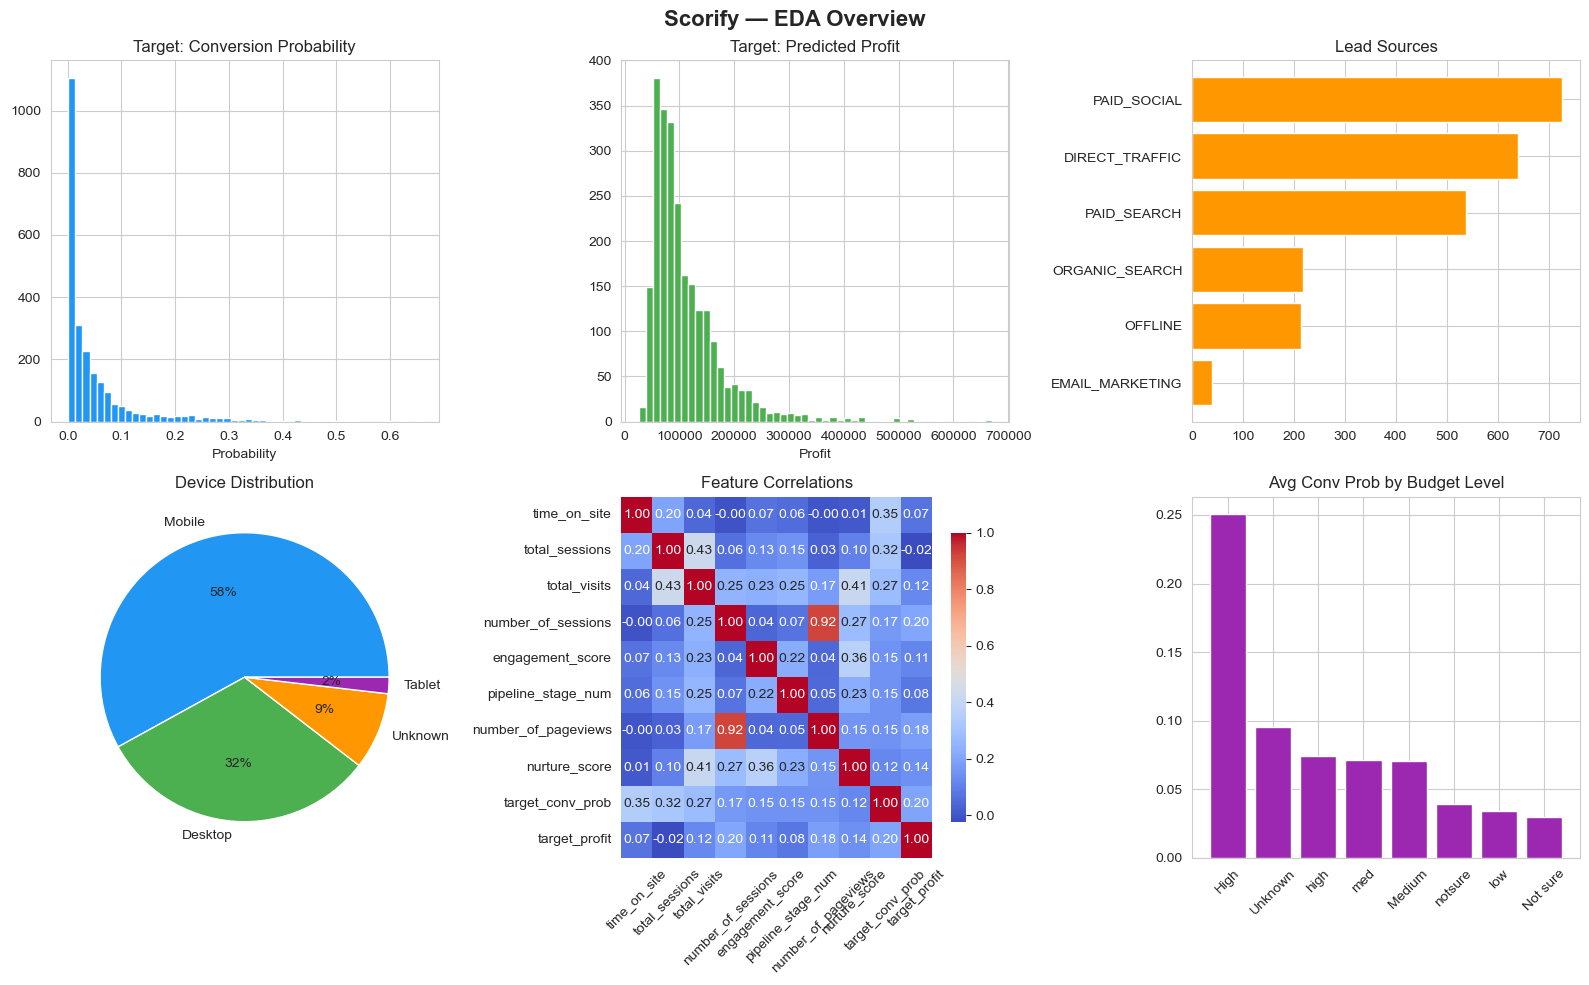


------------------------------------------------------------
SUMMARY
  Input:    raw_data.csv (3931 rows × 224 cols)
  Output:   scorify_cleaned_dataset.csv (2458 rows × 37 cols)
  Features: 28
  Targets:  target_conv_prob, target_profit
  Nulls:    0
  Done.


In [4]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


#LOAD RAW DATA

INPUT_FILE = "raw_data.csv"
OUTPUT_FILE = "scorify_cleaned_dataset.csv"


print(" Data Cleaning & EDA ")


df = pd.read_csv(INPUT_FILE, low_memory=False)
print(f"\n[1] Raw data loaded: {df.shape[0]} rows × {df.shape[1]} columns")


# 2. DEDUPLICATE 

df["_ts"] = pd.to_datetime(df["score_timestamp"], errors="coerce")
df = df.sort_values("_ts").drop_duplicates(subset="record_id", keep="last")
df = df.drop(columns=["_ts"])
print(f"[2] Deduplicated: {df.shape[0]} unique leads (latest per record_id)")


# 3. SELECT & RENAME COLUMNS

COL_MAP = {
    "record_id":                     "record_id",
    "marketing_original_source":     "marketing_original_source",
    "marketing_latest_source":       "marketing_latest_source",
    "device":                        "device",
    "country":                       "country",
    "Feature3":                      "lead_source_detail",
    "Feature5":                      "visitor_type",
    "custom_prop2":                  "destination_interest",
    "Feature2":                      "budget_range",
    "custom_prop1":                  "travel_group_type",
    "custom_prop5":                  "trip_duration",
    "Feature48":                     "budget_level",
    "Feature33":                     "currency",
    "Feature26":                     "age_bracket",
    "Feature34":                     "lead_type",
    "Feature60":                     "booking_intent",
    "Feature6":                      "enquiry_touchpoints",
    "Feature7":                      "form_submissions",
    "Feature18":                     "page_interactions",
    "Feature29":                     "unknown_engagement_1",
    "Feature45":                     "total_visits",
    "Feature46":                     "total_sessions",
    "average_pageviews":             "average_pageviews",
    "number_of_pageviews":           "number_of_pageviews",
    "number_of_sessions":            "number_of_sessions",
    "Feature31":                     "time_on_site",
    "Feature56":                     "returning_visitor",
    "Feature27":                     "engagement_score",
    "Feature32":                     "has_specific_dates",
    "Feature40":                     "sales_activity_count",
    "Feature41":                     "contact_count",
    "Feature42":                     "offer_count",
    "Feature50":                     "response_indicator",
    "Feature52":                     "qualified_flag",
    "Feature44":                     "interaction_depth",
    "Feature43":                     "follow_up_count",
    "Feature53":                     "pipeline_stage_num",
    "Feature54":                     "total_activities",
    "Feature59":                     "deal_progress",
    "Feature61":                     "nurture_score",
    "Feature62":                     "readiness_score",
    "predicted_conv_prob":           "target_conv_prob",
    "predicted_profit_if_converted": "target_profit",
}

df_clean = df[[c for c in COL_MAP if c in df.columns]].copy()
df_clean.columns = [COL_MAP[c] for c in df_clean.columns]
print(f"[3] Selected {df_clean.shape[1]} columns from {df.shape[1]}")


# 4. CLEAN VALUES

for col in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
    df_clean[col] = df_clean[col].replace({"nan": np.nan, "None": np.nan, "": np.nan})

df_clean["country"] = df_clean["country"].str.title()

df_clean["returning_visitor"] = (
    df_clean["returning_visitor"]
    .map({True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0})
    .fillna(0).astype(int)
)
print(f"[4] Cleaned string values, standardized types")


# 5. IMPUTE MISSING VALUES

PROTECTED = ["record_id", "target_conv_prob", "target_profit"]

for col in df_clean.select_dtypes(include=[np.number]).columns:
    if col not in PROTECTED:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in df_clean.select_dtypes(include=["object"]).columns:
    df_clean[col] = df_clean[col].fillna("Unknown")

print(f"[5] Imputed missing values (numeric=median, categorical=Unknown)")


# 6. DROP COLUMNS WHERE ≥95% VALUES ARE NULL OR ZERO

THRESHOLD = 0.95
drop_cols = []

for col in df_clean.columns:
    if col in PROTECTED:
        continue
    total = len(df_clean)
    null_count = df_clean[col].isna().sum()
    if df_clean[col].dtype in ["float64", "int64", "int32"]:
        zero_count = (df_clean[col] == 0).sum()
        useless = (null_count + zero_count) / total
    else:
        useless = null_count / total
    if useless >= THRESHOLD:
        drop_cols.append(col)

df_clean = df_clean.drop(columns=drop_cols)
print(f"[6] Dropped {len(drop_cols)} columns (≥95% null+zero)")


# 7. DROP ZERO-VARIANCE COLUMNS

zero_var = [c for c in df_clean.columns if c not in PROTECTED and df_clean[c].nunique() <= 1]
if zero_var:
    df_clean = df_clean.drop(columns=zero_var)
    print(f"[7] Dropped {len(zero_var)} zero-variance columns: {zero_var}")
else:
    print(f"[7] No zero-variance columns")


# 8. SAVE CLEANED DATA

df_clean.to_csv(OUTPUT_FILE, index=False)
print(f"\n[8] Saved: {OUTPUT_FILE}")
print(f"    Final shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"    Missing values: {df_clean.isnull().sum().sum()}")


# 9. BRIEF EDA 


print("EDA — Key Insights")
print("-" * 60)

num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=["object"]).columns.tolist()
features = [c for c in df_clean.columns if c not in PROTECTED]
print(f"\nDataset: {df_clean.shape[0]} leads, {len(features)} features, 2 targets")
print(f"  Numeric features:     {len([c for c in features if c in num_cols])}")
print(f"  Categorical features: {len([c for c in features if c in cat_cols])}")

print(f"\nTarget 1 — target_conv_prob (conversion probability):")
t1 = df_clean["target_conv_prob"]
print(f"  Mean={t1.mean():.4f}, Median={t1.median():.4f}, Std={t1.std():.4f}")
print(f"  Range=[{t1.min():.4f}, {t1.max():.4f}]")

print(f"\nTarget 2 — target_profit (predicted profit if converted):")
t2 = df_clean["target_profit"]
print(f"  Mean={t2.mean():,.0f}, Median={t2.median():,.0f}, Std={t2.std():,.0f}")
print(f"  Range=[{t2.min():,.0f}, {t2.max():,.0f}]")

num_features = [c for c in num_cols if c not in PROTECTED]
print(f"\nTop feature correlations with target_conv_prob:")
corr1 = df_clean[num_features + ["target_conv_prob"]].corr()["target_conv_prob"].drop("target_conv_prob").abs().sort_values(ascending=False)
for feat, val in corr1.head(5).items():
    print(f"  {feat:30s}: {val:.4f}")

print(f"\nTop feature correlations with target_profit:")
corr2 = df_clean[num_features + ["target_profit"]].corr()["target_profit"].drop("target_profit").abs().sort_values(ascending=False)
for feat, val in corr2.head(5).items():
    print(f"  {feat:30s}: {val:.4f}")


# 10. EDA PLOTS

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Scorify — EDA Overview", fontsize=16, fontweight="bold")


axes[0, 0].hist(df_clean["target_conv_prob"], bins=50, color="#2196F3", edgecolor="white")
axes[0, 0].set_title("Target: Conversion Probability")
axes[0, 0].set_xlabel("Probability")


axes[0, 1].hist(df_clean["target_profit"], bins=50, color="#4CAF50", edgecolor="white")
axes[0, 1].set_title("Target: Predicted Profit")
axes[0, 1].set_xlabel("Profit")


src = df_clean["marketing_original_source"].value_counts().head(6)
axes[0, 2].barh(src.index, src.values, color="#FF9800")
axes[0, 2].set_title("Lead Sources")
axes[0, 2].invert_yaxis()


dev = df_clean["device"].value_counts()
axes[1, 0].pie(dev.values, labels=dev.index, autopct="%1.0f%%",
               colors=["#2196F3", "#4CAF50", "#FF9800", "#9C27B0"])
axes[1, 0].set_title("Device Distribution")


top_feats = corr1.head(8).index.tolist()
corr_matrix = df_clean[top_feats + ["target_conv_prob", "target_profit"]].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1],
            xticklabels=True, yticklabels=True, cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("Feature Correlations")
axes[1, 1].tick_params(axis="x", rotation=45)


if "budget_level" in df_clean.columns:
    budget_conv = df_clean.groupby("budget_level")["target_conv_prob"].mean().sort_values(ascending=False)
    axes[1, 2].bar(budget_conv.index, budget_conv.values, color="#9C27B0")
    axes[1, 2].set_title("Avg Conv Prob by Budget Level")
    axes[1, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()


# FINAL SUMMARY

print("\n" + "-" * 60)
print("SUMMARY")

print(f"  Input:    {INPUT_FILE} ({3931} rows × 224 cols)")
print(f"  Output:   {OUTPUT_FILE} ({df_clean.shape[0]} rows × {df_clean.shape[1]} cols)")
print(f"  Features: {len(features) - len(drop_cols) - len(zero_var)}")
print(f"  Targets:  target_conv_prob, target_profit")
print(f"  Nulls:    {df_clean.isnull().sum().sum()}")
print("  Done.")